In [4]:
import re
import warnings
from collections import Counter

import hdbscan
import nltk
import numpy as np
import pandas as pd
import umap
from matplotlib import pyplot as plt
from nltk import word_tokenize
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")

nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
def tokenize(text):
    """Токенизирует входящий текст"""
    text = text.lower()
    text = re.sub(r'[^а-яa-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


🔄 Кодируем тексты в эмбеддинги...


Batches:   0%|          | 0/177 [00:00<?, ?it/s]

✅ Получено 5649 эмбеддингов размерности 1024

🔍 Выполняем кластеризацию HDBSCAN...

📈 Метрики качества кластеров:
Silhouette Score: 0.1536
Davies–Bouldin Index: 1.5986
Calinski–Harabasz Score: 31.5

📊 Распределение по кластерам:
cluster
-1      3210
 0         6
 1         5
 2         7
 3         6
        ... 
 162       7
 163       5
 164      36
 165      34
 166       6
Name: count, Length: 168, dtype: int64

Кластер 0 (6 событий): ['всу', 'освободили', 'балаклею', 'изюм', 'купянск', 'лиман', 'снигирвку', 'херсон', 'берислав', 'оккупировали']

Кластер 1 (5 событий): ['рекорд', 'воздушном', 'шаре', 'стив', 'фоссетт', 'мире', 'российский', 'космосе', 'дней', 'американец']

Кластер 2 (7 событий): ['год', 'премию', 'сша', 'премии', 'нобелевская', 'премия', 'присуждена', 'физике', 'англ', 'университет']

Кластер 3 (6 событий): ['войны', 'начало', 'гражданской', 'тыграе', 'израиля', 'ливаном', 'сирии', 'второй', 'карабахской', 'мьянме']

Кластер 4 (5 событий): ['рекорд', 'c', 'годом',

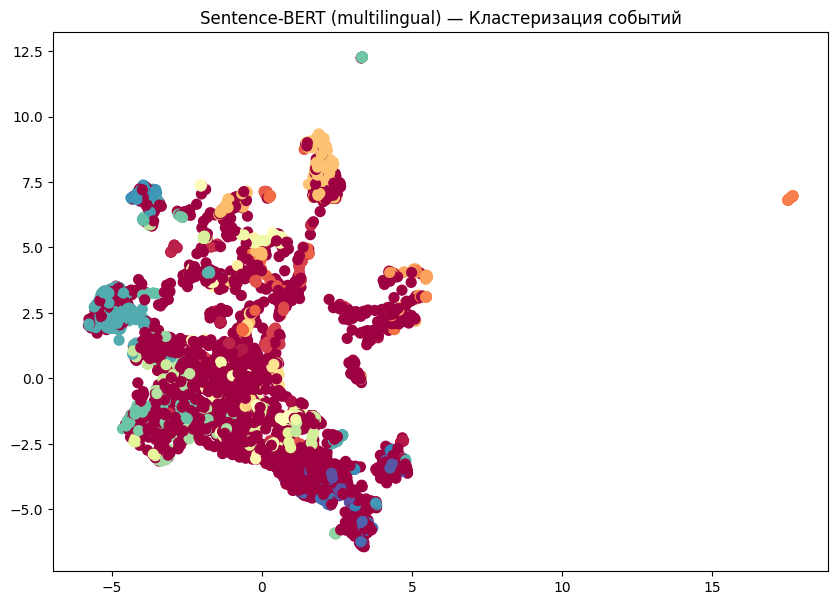

In [6]:
# === 2. Данные ===
df = pd.read_csv("../events/2_struct/2000-2025.csv")  #

# === 3. Модель Sentence-BERT (многоязычная, понимает русский) ===
model = SentenceTransformer('ai-forever/sbert_large_nlu_ru')

# === 4. Кодирование текстов ===
print("🔄 Кодируем тексты в эмбеддинги...")
X = model.encode(df["event"], show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
X = X.astype(np.float64)
print(f"✅ Получено {X.shape[0]} эмбеддингов размерности {X.shape[1]}")

# === 5. Кластеризация HDBSCAN ===
print("\n🔍 Выполняем кластеризацию HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=1,
    metric='cosine',
    algorithm='generic',
)
labels = clusterer.fit_predict(X)
df["cluster"] = labels

# === 6. Метрики кластеризации ===
mask = labels != -1  # убираем шум
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])
    ch = calinski_harabasz_score(X[mask], labels[mask])
    print(f"\n📈 Метрики качества кластеров:")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies–Bouldin Index: {db:.4f}")
    print(f"Calinski–Harabasz Score: {ch:.1f}")
else:
    print("Недостаточно кластеров для расчёта метрик (все тексты попали в один кластер).")

# === 7. Сводка по кластерам ===
print("\n📊 Распределение по кластерам:")
print(df["cluster"].value_counts().sort_index())

df["tokens"] = df["event"].apply(tokenize)

for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = Counter(tokens).most_common(10)
    print(f"\nКластер {cluster_id} ({len(subset)} событий): {[w for w, _ in common]}")

# === 9. Визуализация UMAP ===
print("\n🎨 Строим 2D-визуализацию UMAP...")
umap_embeddings = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=df["cluster"], cmap="Spectral", s=50)
plt.title("Sentence-BERT (multilingual) — Кластеризация событий")
plt.show()